In [624]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import root_mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer

In [625]:
RANDOM_SEED = 42
TEST_RATIO = 0.2
DATA_BASE_PATH = Path("./data")

In [626]:
gold_file_path = DATA_BASE_PATH / "final_gold_data.csv"

In [627]:
gold = pd.read_csv(gold_file_path, sep=";", encoding="utf-8", parse_dates=["timestamp"])
gold.head()

,timestamp,open,high,low,close,volume,currency,unit,headlines
0,2000-08-30,273.9,273.9,273.9,273.9,0,usd,ounce,Recalls Fuel Disclosure Debate / Deutsche Tele...
1,2000-08-31,274.8,278.3,274.8,278.3,0,usd,ounce,Credit Suisse's Wheat Faces Deal / Regulators ...
2,2000-09-01,277.0,277.0,277.0,277.0,0,usd,ounce,Nordstrom's Chief Resigns / Judge Dismisses Ca...
3,2000-09-05,275.8,275.8,275.8,275.8,2,usd,ounce,Market Pace Slows After 10-Year Run / Clickman...
4,2000-09-06,274.2,274.2,274.2,274.2,0,usd,ounce,France Telecom Profit Increases / Locale-Based...


In [628]:
gold.describe()

,timestamp,open,high,low,close,volume
count,6177,6177.000000,6177.000000,6177.000000,6177.000000,6177.000000
mean,2012-12-29 00:01:09.936862464,1181.017241,1186.953392,1174.885090,1181.012304,4298.049377
min,2000-08-30 00:00:00,255.000000,256.100000,255.000000,255.100000,0.000000
25%,2006-11-09 00:00:00,636.500000,640.200000,634.000000,635.200000,21.000000
50%,2012-12-31 00:00:00,1238.200000,1243.900000,1231.800000,1238.400000,108.000000
75%,2019-02-25 00:00:00,1641.300000,1652.200000,1630.400000,1640.300000,415.000000
max,2025-04-14 00:00:00,3215.500000,3235.000000,3194.500000,3222.200000,386334.000000
std,NaN,606.257425,609.741360,602.902334,606.424369,24281.911885


In [629]:
gold["currency"].value_counts()

currency
usd    6177
Name: count, dtype: int64

In [630]:
gold["unit"].value_counts()

unit
ounce    6177
Name: count, dtype: int64

In [631]:
gold.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6177 entries, 0 to 6176
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   timestamp  6177 non-null   datetime64[ns]
 1   open       6177 non-null   float64       
 2   high       6177 non-null   float64       
 3   low        6177 non-null   float64       
 4   close      6177 non-null   float64       
 5   volume     6177 non-null   int64         
 6   currency   6177 non-null   object        
 7   unit       6177 non-null   object        
 8   headlines  6177 non-null   object        
dtypes: datetime64[ns](1), float64(4), int64(1), object(3)
memory usage: 434.4+ KB


In [632]:
gold["day_variation"] = gold["open"] - gold["close"]
gold["max_diff"] = gold["high"] - gold["low"]

In [633]:
gold[["day_variation", "max_diff"]].describe()

,day_variation,max_diff
count,6177.000000,6177.000000
mean,0.004938,12.068302
std,12.019223,13.161586
min,-90.700000,-1.300000
25%,-4.000000,2.500000
50%,0.000000,9.100000
75%,3.400000,17.100000
max,117.600000,149.400000


array([[<Axes: title={'center': 'day_variation'}>,
        <Axes: title={'center': 'max_diff'}>]], dtype=object)

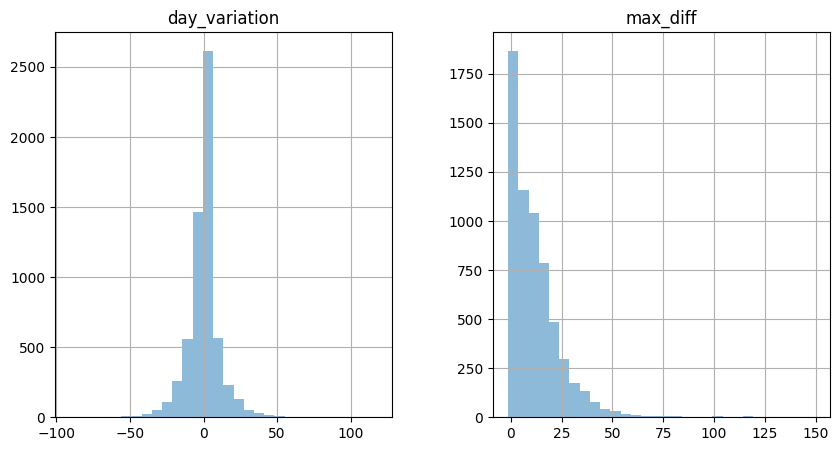

In [634]:
gold[["day_variation", "max_diff"]].hist(bins=30, alpha=0.5, figsize=(10, 5))

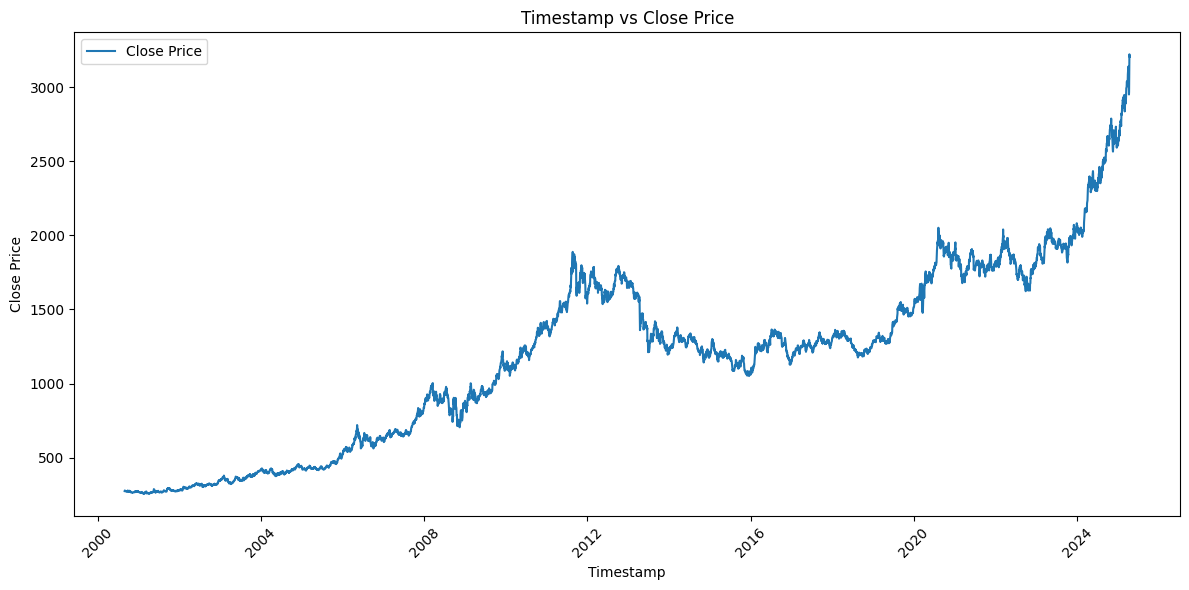

In [635]:
plt.figure(figsize=(12, 6))
plt.plot(gold["timestamp"], gold["close"], label="Close Price")
plt.xlabel("Timestamp")
plt.ylabel("Close Price")
plt.title("Timestamp vs Close Price")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

array([[<Axes: xlabel='high', ylabel='high'>,
        <Axes: xlabel='low', ylabel='high'>,
        <Axes: xlabel='open', ylabel='high'>,
        <Axes: xlabel='close', ylabel='high'>],
       [<Axes: xlabel='high', ylabel='low'>,
        <Axes: xlabel='low', ylabel='low'>,
        <Axes: xlabel='open', ylabel='low'>,
        <Axes: xlabel='close', ylabel='low'>],
       [<Axes: xlabel='high', ylabel='open'>,
        <Axes: xlabel='low', ylabel='open'>,
        <Axes: xlabel='open', ylabel='open'>,
        <Axes: xlabel='close', ylabel='open'>],
       [<Axes: xlabel='high', ylabel='close'>,
        <Axes: xlabel='low', ylabel='close'>,
        <Axes: xlabel='open', ylabel='close'>,
        <Axes: xlabel='close', ylabel='close'>]], dtype=object)

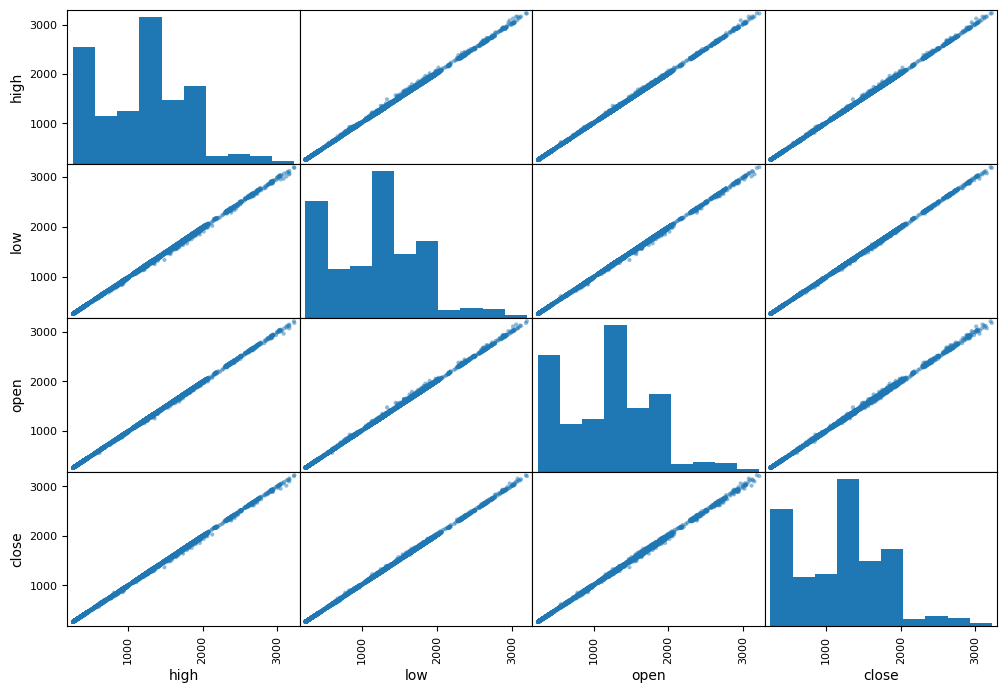

In [636]:
price_cols = ["high", "low", "open", "close"]
scatter_matrix(gold[price_cols], figsize=(12, 8))

In [637]:
gold[price_cols].corr()

,high,low,open,close
high,1.000000,0.999828,0.999906,0.999891
low,0.999828,1.000000,0.999872,0.999916
open,0.999906,0.999872,1.000000,0.999804
close,0.999891,0.999916,0.999804,1.000000


In [638]:
gold["tomorrow_close"] = gold["close"].shift(-30)
gold = gold.dropna(subset=["tomorrow_close"])  # Remove last row with NaN
gold.head()

,timestamp,open,high,low,close,volume,currency,unit,headlines,day_variation,max_diff,tomorrow_close
0,2000-08-30,273.9,273.9,273.9,273.9,0,usd,ounce,Recalls Fuel Disclosure Debate / Deutsche Tele...,0.0,0.0,276.4
1,2000-08-31,274.8,278.3,274.8,278.3,0,usd,ounce,Credit Suisse's Wheat Faces Deal / Regulators ...,-3.5,3.5,272.4
2,2000-09-01,277.0,277.0,277.0,277.0,0,usd,ounce,Nordstrom's Chief Resigns / Judge Dismisses Ca...,0.0,0.0,271.5
3,2000-09-05,275.8,275.8,275.8,275.8,2,usd,ounce,Market Pace Slows After 10-Year Run / Clickman...,0.0,0.0,271.1
4,2000-09-06,274.2,274.2,274.2,274.2,0,usd,ounce,France Telecom Profit Increases / Locale-Based...,0.0,0.0,270.3


<Axes: >

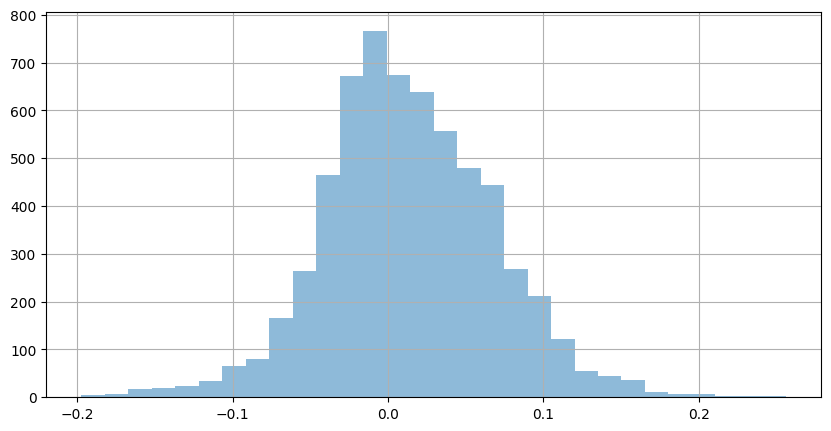

In [639]:
gold["return"] = (gold["tomorrow_close"] - gold["close"]) / gold[
    "close"
]  # return might be our target
gold["return"].hist(bins=30, alpha=0.5, figsize=(10, 5))

In [640]:
value_cols = price_cols + ["return", "max_diff", "day_variation"]

gold[value_cols].describe()

,high,low,open,close,return,max_diff,day_variation
count,6147.000000,6147.000000,6147.000000,6147.000000,6147.000000,6147.000000,6147.000000
mean,1177.874947,1165.964845,1172.044038,1172.012754,0.013291,11.910102,0.031284
std,597.147225,590.631254,593.904550,593.993870,0.054814,12.798921,11.752330
min,256.100000,255.000000,255.000000,255.100000,-0.197478,-1.300000,-73.500000
25%,636.550000,632.050000,634.650000,633.800000,-0.021777,2.450000,-4.000000
50%,1242.800000,1229.500000,1236.200000,1236.200000,0.009890,9.000000,0.000000
75%,1641.600000,1619.850000,1629.250000,1628.400000,0.049393,17.000000,3.400000
max,2957.900000,2933.100000,2949.100000,2947.900000,0.256195,149.400000,117.600000


array([[<Axes: xlabel='high', ylabel='high'>,
        <Axes: xlabel='low', ylabel='high'>,
        <Axes: xlabel='open', ylabel='high'>,
        <Axes: xlabel='close', ylabel='high'>,
        <Axes: xlabel='return', ylabel='high'>,
        <Axes: xlabel='max_diff', ylabel='high'>,
        <Axes: xlabel='day_variation', ylabel='high'>],
       [<Axes: xlabel='high', ylabel='low'>,
        <Axes: xlabel='low', ylabel='low'>,
        <Axes: xlabel='open', ylabel='low'>,
        <Axes: xlabel='close', ylabel='low'>,
        <Axes: xlabel='return', ylabel='low'>,
        <Axes: xlabel='max_diff', ylabel='low'>,
        <Axes: xlabel='day_variation', ylabel='low'>],
       [<Axes: xlabel='high', ylabel='open'>,
        <Axes: xlabel='low', ylabel='open'>,
        <Axes: xlabel='open', ylabel='open'>,
        <Axes: xlabel='close', ylabel='open'>,
        <Axes: xlabel='return', ylabel='open'>,
        <Axes: xlabel='max_diff', ylabel='open'>,
        <Axes: xlabel='day_variation', ylabel='op

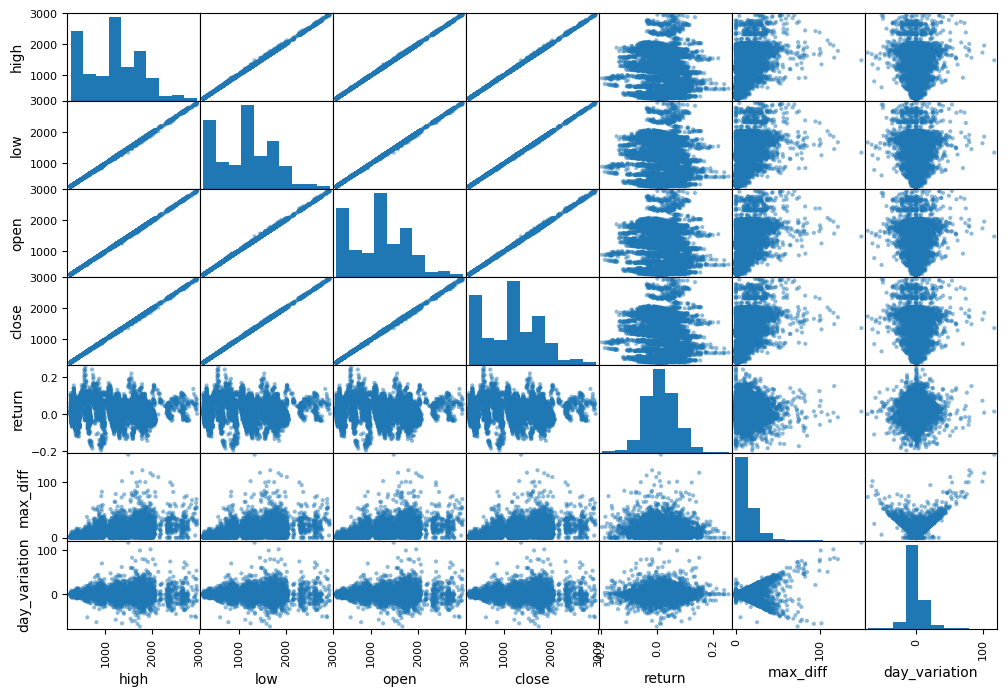

In [641]:
scatter_matrix(gold[value_cols], figsize=(12, 8))

In [642]:
gold[value_cols].corr()

,high,low,open,close,return,max_diff,day_variation
high,1.000000,0.999828,0.999908,0.999891,-0.065778,0.517042,-0.006756
low,0.999828,1.000000,0.999871,0.999916,-0.065405,0.501076,-0.009862
open,0.999908,0.999871,1.000000,0.999804,-0.065522,0.510771,0.002293
close,0.999891,0.999916,0.999804,1.000000,-0.065908,0.507926,-0.017492
return,-0.065778,-0.065405,-0.065522,-0.065908,1.000000,-0.050687,0.019970
max_diff,0.517042,0.501076,0.510771,0.507926,-0.050687,1.000000,0.139885
day_variation,-0.006756,-0.009862,0.002293,-0.017492,0.019970,0.139885,1.000000


In [643]:
gold["month"] = gold["timestamp"].dt.month
gold["year"] = gold["timestamp"].dt.year
gold = pd.get_dummies(gold, columns=["month", "year"], drop_first=True)
gold.head()

,timestamp,open,high,low,close,volume,currency,unit,headlines,day_variation,...,year_2016,year_2017,year_2018,year_2019,year_2020,year_2021,year_2022,year_2023,year_2024,year_2025
0,2000-08-30,273.9,273.9,273.9,273.9,0,usd,ounce,Recalls Fuel Disclosure Debate / Deutsche Tele...,0.0,...,False,False,False,False,False,False,False,False,False,False
1,2000-08-31,274.8,278.3,274.8,278.3,0,usd,ounce,Credit Suisse's Wheat Faces Deal / Regulators ...,-3.5,...,False,False,False,False,False,False,False,False,False,False
2,2000-09-01,277.0,277.0,277.0,277.0,0,usd,ounce,Nordstrom's Chief Resigns / Judge Dismisses Ca...,0.0,...,False,False,False,False,False,False,False,False,False,False
3,2000-09-05,275.8,275.8,275.8,275.8,2,usd,ounce,Market Pace Slows After 10-Year Run / Clickman...,0.0,...,False,False,False,False,False,False,False,False,False,False
4,2000-09-06,274.2,274.2,274.2,274.2,0,usd,ounce,France Telecom Profit Increases / Locale-Based...,0.0,...,False,False,False,False,False,False,False,False,False,False


In [644]:
TARGET = "tomorrow_close"
to_drop = [
    "currency",
    "unit",
    "day_variation",
    "max_diff",
    "timestamp",
    "close",
    "return",
    "high",
    "low",
    # "volume",
    # "open",
]
X = gold.drop(columns=to_drop + [TARGET], axis=1)
y = gold[TARGET]

In [645]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_RATIO, random_state=RANDOM_SEED, shuffle=True
)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((4917, 39), (1230, 39), (4917,), (1230,))

In [646]:
# X_train = X_train.reset_index(drop=True)
# X_test = X_test.reset_index(drop=True)

# y_train = y_train.reset_index(drop=True)
# y_test = y_test.reset_index(drop=True)

In [647]:
vectorizer = TfidfVectorizer(
    stop_words="english", max_features=1000, ngram_range=(1, 2), min_df=5, max_df=0.8
)
tfidf_vectorized_matrix = vectorizer.fit_transform(X_train["headlines"])
TfidfMatrix = pd.DataFrame(
    tfidf_vectorized_matrix.toarray(), columns=vectorizer.get_feature_names_out()
)  # type: ignore
TfidfMatrix.head()

,000,10,100,11,12,15,19,20,2020,30,...,year,year high,years,yen,yield,yields,york,york city,yuan,zone
0,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,...,0.060316,0.0,0.0,0.000000,0.095563,0.0,0.0,0.0,0.0,0.0
1,0.123693,0.0,0.0,0.000000,0.0,0.141254,0.000000,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
2,0.000000,0.0,0.0,0.122994,0.0,0.000000,0.000000,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.105234,0.000000,0.0,0.0,0.0,0.0,0.0
3,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.124953,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
4,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0


In [648]:
sum_words = TfidfMatrix.sum(axis=0)
words_freq = [
    (word, sum_words.iloc[idx]) for word, idx in vectorizer.vocabulary_.items()
]
sorted_words = sorted(words_freq, key=lambda x: x[1], reverse=True)

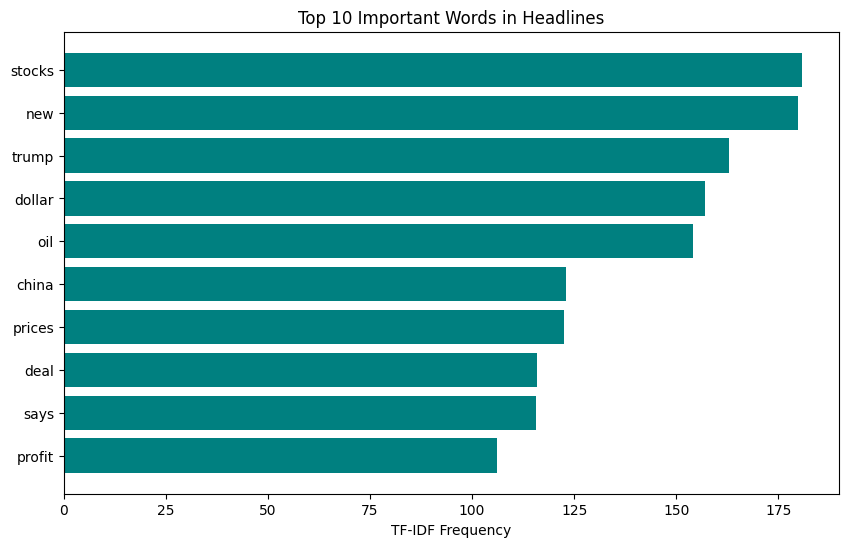

In [649]:
# Extract top N words and their frequencies
top_n = 10
words = [word for word, _ in sorted_words[:top_n]]
frequencies = [freq for _, freq in sorted_words[:top_n]]

# Plotting
plt.figure(figsize=(10, 6))
plt.barh(words, frequencies, color="teal")
plt.xlabel("TF-IDF Frequency")
plt.title(f"Top {top_n} Important Words in Headlines")
plt.gca().invert_yaxis()  # To have the highest bar at the top
plt.show()

In [650]:
def contain_word(series: pd.Series, word: str) -> pd.Series:
    """
    Check if a word is contained in the headlines.
    """
    return series.str.contains(word, case=False, na=False)

In [651]:
for word in words:
    X_train[word] = contain_word(X_train["headlines"], word)
    X_test[word] = contain_word(X_test["headlines"], word)

In [652]:
X_train.drop(columns=["headlines"], inplace=True)
X_test.drop(columns=["headlines"], inplace=True)

In [653]:
X_train.head()

,open,volume,month_2,month_3,month_4,month_5,month_6,month_7,month_8,month_9,...,stocks,new,trump,dollar,oil,china,prices,deal,says,profit
2480,1183.4,2504,False,False,False,False,False,False,True,False,...,True,True,False,False,True,False,False,False,False,False
5321,1853.6,1,False,False,False,False,False,False,False,False,...,False,False,False,True,True,False,False,True,True,False
443,320.1,67,False,False,False,False,True,False,False,False,...,False,True,False,True,False,True,True,False,False,True
5001,2012.4,971,False,False,False,False,False,False,True,False,...,False,True,False,False,False,False,False,True,True,False
3567,1197.7,17,False,False,False,False,False,False,False,False,...,False,True,False,False,False,True,False,True,False,False


In [654]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [655]:
model = Ridge(alpha=7000)

In [656]:
model.fit(X_train_scaled, y_train)

Ridge(alpha=7000)

In [657]:
y_pred = model.predict(X_test_scaled)

In [658]:
model.score(X_test_scaled, y_test)

0.8303355832252411

In [659]:
rmse = root_mean_squared_error(y_test, y_pred)
print("Square root of RMSE:", rmse)

Square root of RMSE: 253.73957910844823


In [660]:
gold[TARGET].describe()

count    6147.000000
mean     1185.444135
std       604.566616
min       255.100000
25%       644.600000
50%      1240.100000
75%      1642.100000
max      3222.200000
Name: tomorrow_close, dtype: float64

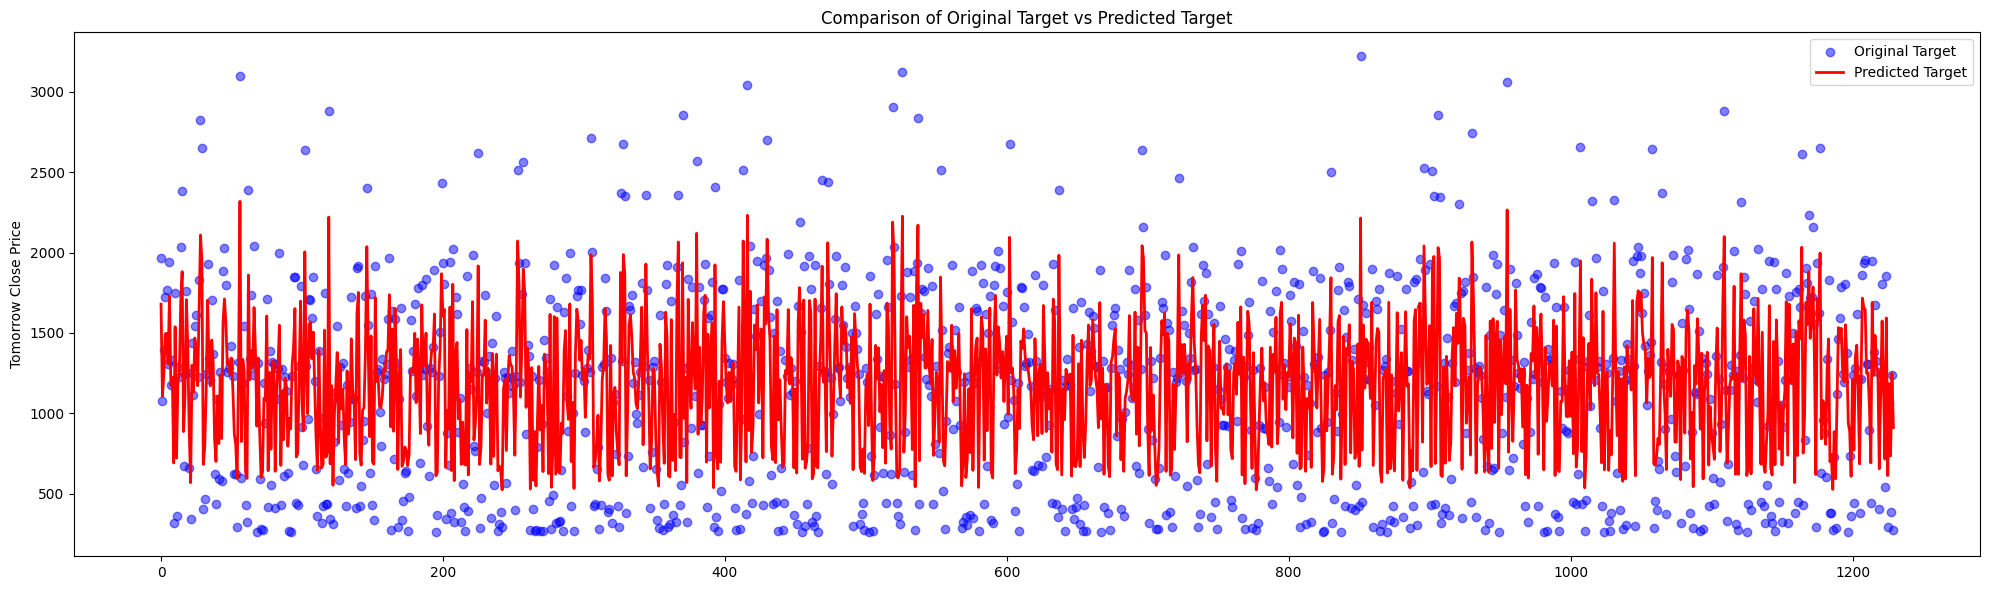

In [661]:
# Plot the original target vs predicted values
plt.figure(figsize=(20, 6))
plt.scatter(
    range(len(y_test)), y_test, label="Original Target", color="blue", alpha=0.5
)
plt.plot(range(len(y_test)), y_pred, label="Predicted Target", color="red", linewidth=2)
plt.ylabel("Tomorrow Close Price")
plt.title("Comparison of Original Target vs Predicted Target")
plt.legend()
plt.tight_layout()
plt.show()

In [662]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import Pipeline

# Define KFold cross-validator
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

pipeline = Pipeline([("scaler", StandardScaler()), ("model", LinearRegression())])

numerical_X = X.drop(columns=["headlines"], axis=1)

# Perform cross-validation using KFold with scaled data
cv_scores = cross_val_score(pipeline, numerical_X, y, cv=kf, scoring="r2")

# Print the cross-validation scores and their mean
print("Cross-validation scores:", cv_scores)
print("Mean cross-validation score:", cv_scores.mean())

Cross-validation scores: [0.99149561 0.99171478 0.99034937 0.99243068 0.99060813]
Mean cross-validation score: 0.991319713091027
